In [1]:
import sys
from pathlib import Path

def find_project_root(markers=("src", "Data", "Notebooks")):
    current_path = Path.cwd().resolve()

    for path in [current_path] + list(current_path.parents):
        has_all_markers = all((path / marker).exists() for marker in markers)
        if has_all_markers:
            return path

    raise RuntimeError(f"Project root could not be found from: {current_path}")

project_root = find_project_root()
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import paths as P
import pandas as pd
import re

In [2]:
# load the cleaned decision-log dataset and coding sheet

decision_file = P.decision_logs_cleaned_with_ids_file
coding_file = P.decision_logs_documentation_dir / "Decision Log Final Coding Scheme.xlsx"

decision_df = pd.read_csv(decision_file)
coding_df = pd.read_excel(coding_file)

print("Decision log dataset shape:", decision_df.shape)
print("Coding sheet shape:", coding_df.shape)
print()

print("Coding sheet columns:")
print(coding_df.columns.tolist())

display(coding_df.head(10))

Decision log dataset shape: (2009, 24)
Coding sheet shape: (45, 6)

Coding sheet columns:
['Full scenario brief', 'Choice Title', 'Decision Orientation', 'Risk Management', 'Human Element', 'Transparency']


,Full scenario brief,Choice Title,Decision Orientation,Risk Management,Human Element,Transparency
0,"During a routine review of mail gateway logs, ...",Immediate University-Wide Warning. Send an imm...,Explicit balancing approach,Reactive/delayed,Supportive/enabling,Open/transparency-first
1,NaN,Investigate Before Communicating. Quietly inve...,Operational continuity prioritised,Investigative/monitoring,Surveillance-oriented,Selective disclosure
2,NaN,Block and Monitor Without Warning. Block the s...,Security/risk reduction prioritised,Containment/defensive,Surveillance-oriented,Concealed/quiet handling
3,"At the start of the academic year, a scheduled...",Take the System Offline Immediately. Take the ...,Security/risk reduction prioritised,Containment/defensive,Enforcement/punitive,Open/transparency-first
4,NaN,Monitor and Delay Action. Leave the system run...,Operational continuity prioritised,Risk acceptance/tolerance,Surveillance-oriented,Concealed/quiet handling
5,NaN,Apply Temporary Mitigations. Restrict network ...,Explicit balancing approach,Investigative/monitoring,Surveillance-oriented,Selective disclosure
6,While reviewing access logs for the assessment...,Individual Accounts with MFA. Introduce named ...,Explicit balancing approach,Preventive/proactive,Supportive/enabling,Open/transparency-first
7,NaN,Temporary Sharing with a Deadline. Allow tempo...,Operational continuity prioritised,Risk acceptance/tolerance,Neutral,Selective disclosure
8,NaN,Enforce Individual Accounts. Require staff to ...,Security/risk reduction prioritised,Reactive/delayed,Enforcement/punitive,Selective disclosure
9,The IT helpdesk reports that multiple machines...,Shut Down the Lab Immediately. Take the entire...,Security/risk reduction prioritised,Containment/defensive,Enforcement/punitive,Open/transparency-first


In [4]:
# clean the coding sheet into a proper 45-row reference table
coding_clean = coding_df.copy()

# 1. fill down the scenario brief within each 3-choice block
coding_clean["Full scenario brief"] = coding_clean["Full scenario brief"].ffill()

# 2. clean text helper
def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text).replace("\r\n", " ").replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

# apply general cleaning
for col in coding_clean.columns:
    coding_clean[col] = coding_clean[col].apply(clean_text)

# 3. keep original full choice text, but make a clean short title for merging
coding_clean["choice_title_clean"] = (
    coding_clean["Choice Title"]
    .str.split(". ", n=1, regex=False)
    .str[0]
    .str.strip()
)

# quick checks
print("Coding clean shape:", coding_clean.shape)
print("Missing scenario briefs:", coding_clean["Full scenario brief"].isna().sum())
print("Unique scenario briefs:", coding_clean["Full scenario brief"].nunique())
print("Unique cleaned choice titles:", coding_clean["choice_title_clean"].nunique())
print()

display(coding_clean.head(10))

Coding clean shape: (45, 7)
Missing scenario briefs: 0
Unique scenario briefs: 15
Unique cleaned choice titles: 45



,Full scenario brief,Choice Title,Decision Orientation,Risk Management,Human Element,Transparency,choice_title_clean
0,"During a routine review of mail gateway logs, ...",Immediate University-Wide Warning. Send an imm...,Explicit balancing approach,Reactive/delayed,Supportive/enabling,Open/transparency-first,Immediate University-Wide Warning
1,"During a routine review of mail gateway logs, ...",Investigate Before Communicating. Quietly inve...,Operational continuity prioritised,Investigative/monitoring,Surveillance-oriented,Selective disclosure,Investigate Before Communicating
2,"During a routine review of mail gateway logs, ...",Block and Monitor Without Warning. Block the s...,Security/risk reduction prioritised,Containment/defensive,Surveillance-oriented,Concealed/quiet handling,Block and Monitor Without Warning
3,"At the start of the academic year, a scheduled...",Take the System Offline Immediately. Take the ...,Security/risk reduction prioritised,Containment/defensive,Enforcement/punitive,Open/transparency-first,Take the System Offline Immediately
4,"At the start of the academic year, a scheduled...",Monitor and Delay Action. Leave the system run...,Operational continuity prioritised,Risk acceptance/tolerance,Surveillance-oriented,Concealed/quiet handling,Monitor and Delay Action
5,"At the start of the academic year, a scheduled...",Apply Temporary Mitigations. Restrict network ...,Explicit balancing approach,Investigative/monitoring,Surveillance-oriented,Selective disclosure,Apply Temporary Mitigations
6,While reviewing access logs for the assessment...,Individual Accounts with MFA. Introduce named ...,Explicit balancing approach,Preventive/proactive,Supportive/enabling,Open/transparency-first,Individual Accounts with MFA
7,While reviewing access logs for the assessment...,Temporary Sharing with a Deadline. Allow tempo...,Operational continuity prioritised,Risk acceptance/tolerance,Neutral,Selective disclosure,Temporary Sharing with a Deadline
8,While reviewing access logs for the assessment...,Enforce Individual Accounts. Require staff to ...,Security/risk reduction prioritised,Reactive/delayed,Enforcement/punitive,Selective disclosure,Enforce Individual Accounts
9,The IT helpdesk reports that multiple machines...,Shut Down the Lab Immediately. Take the entire...,Security/risk reduction prioritised,Containment/defensive,Enforcement/punitive,Open/transparency-first,Shut Down the Lab Immediately


In [5]:
# standardise merge keys in both datasets
def clean_merge_text(text):
    if pd.isna(text):
        return text
    text = str(text).replace("\r\n", " ").replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

decision_df["scenario_merge"] = decision_df["decisionLog_scenario"].apply(clean_merge_text)
decision_df["choice_merge"] = decision_df["decisionLog_choice"].apply(clean_merge_text)

coding_clean["scenario_merge"] = coding_clean["Full scenario brief"].apply(clean_merge_text)
coding_clean["choice_merge"] = coding_clean["choice_title_clean"].apply(clean_merge_text)

# quick checks before merge
print("Decision dataset unique scenario-choice pairs:",
      decision_df[["scenario_merge", "choice_merge"]].drop_duplicates().shape[0])

print("Coding dataset unique scenario-choice pairs:",
      coding_clean[["scenario_merge", "choice_merge"]].drop_duplicates().shape[0])

display(
    coding_clean[[
        "scenario_merge",
        "choice_merge",
        "Decision Orientation",
        "Risk Management",
        "Human Element",
        "Transparency"
    ]].head(10)
)

Decision dataset unique scenario-choice pairs: 45
Coding dataset unique scenario-choice pairs: 45


,scenario_merge,choice_merge,Decision Orientation,Risk Management,Human Element,Transparency
0,"During a routine review of mail gateway logs, ...",Immediate University-Wide Warning,Explicit balancing approach,Reactive/delayed,Supportive/enabling,Open/transparency-first
1,"During a routine review of mail gateway logs, ...",Investigate Before Communicating,Operational continuity prioritised,Investigative/monitoring,Surveillance-oriented,Selective disclosure
2,"During a routine review of mail gateway logs, ...",Block and Monitor Without Warning,Security/risk reduction prioritised,Containment/defensive,Surveillance-oriented,Concealed/quiet handling
3,"At the start of the academic year, a scheduled...",Take the System Offline Immediately,Security/risk reduction prioritised,Containment/defensive,Enforcement/punitive,Open/transparency-first
4,"At the start of the academic year, a scheduled...",Monitor and Delay Action,Operational continuity prioritised,Risk acceptance/tolerance,Surveillance-oriented,Concealed/quiet handling
5,"At the start of the academic year, a scheduled...",Apply Temporary Mitigations,Explicit balancing approach,Investigative/monitoring,Surveillance-oriented,Selective disclosure
6,While reviewing access logs for the assessment...,Individual Accounts with MFA,Explicit balancing approach,Preventive/proactive,Supportive/enabling,Open/transparency-first
7,While reviewing access logs for the assessment...,Temporary Sharing with a Deadline,Operational continuity prioritised,Risk acceptance/tolerance,Neutral,Selective disclosure
8,While reviewing access logs for the assessment...,Enforce Individual Accounts,Security/risk reduction prioritised,Reactive/delayed,Enforcement/punitive,Selective disclosure
9,The IT helpdesk reports that multiple machines...,Shut Down the Lab Immediately,Security/risk reduction prioritised,Containment/defensive,Enforcement/punitive,Open/transparency-first


In [6]:
# the cleaned coding reference table

coding_clean_file = P.decision_logs_documentation_dir / "decision_log_final_coding_scheme_cleaned.csv"
coding_clean.to_csv(coding_clean_file, index=False)

print("Saved cleaned coding reference table to:")
print(coding_clean_file)

Saved cleaned coding reference table to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Data\Decision_Logs\Documentation\decision_log_final_coding_scheme_cleaned.csv


In [ ]:
# merge the coding dimensions into the cleaned decision-log dataset

coding_merge = coding_clean[[
    "scenario_merge",
    "choice_merge",
    "Decision Orientation",
    "Risk Management",
    "Human Element",
    "Transparency"
]].copy()

coded_decision_df = decision_df.merge(
    coding_merge,
    on=["scenario_merge", "choice_merge"],
    how="left",
    validate="many_to_one"
)

print("Coded decision dataset shape:", coded_decision_df.shape)
print()

print("Missing Decision Orientation:", coded_decision_df["Decision Orientation"].isna().sum())
print("Missing Risk Management:", coded_decision_df["Risk Management"].isna().sum())
print("Missing Human Element:", coded_decision_df["Human Element"].isna().sum())
print("Missing Transparency:", coded_decision_df["Transparency"].isna().sum())
print()

display(
    coded_decision_df[[
        "run_id",
        "scenario_id",
        "choice_id",
        "decisionLog_choice",
        "Decision Orientation",
        "Risk Management",
        "Human Element",
        "Transparency"
    ]].head(10)
)

Coded decision dataset shape: (2009, 30)

Missing Decision Orientation: 142
Missing Risk Management: 142
Missing Human Element: 142
Missing Transparency: 142



,run_id,scenario_id,choice_id,decisionLog_choice,Decision Orientation,Risk Management,Human Element,Transparency
0,run_1776087643609_b1186f57813e18,F,F2,Negotiate While Recovering,Explicit balancing approach,Reactive/delayed,Neutral,Selective disclosure
1,run_1776087643609_b1186f57813e18,O,O2,Move to Third-Party Cloud,NaN,NaN,NaN,NaN
2,run_1776087643609_b1186f57813e18,J,J3,Phased Access Review,Explicit balancing approach,Investigative/monitoring,Surveillance-oriented,Selective disclosure
3,run_1776087643609_b1186f57813e18,B,B3,Apply Temporary Mitigations,Explicit balancing approach,Investigative/monitoring,Surveillance-oriented,Selective disclosure
4,run_1776087643609_b1186f57813e18,L,L2,Optional Training Modules,Explicit balancing approach,Preventive/proactive,Supportive/enabling,Selective disclosure
5,run_1776087643609_b1186f57813e18,A,A1,Immediate University-Wide Warning,Explicit balancing approach,Reactive/delayed,Supportive/enabling,Open/transparency-first
6,run_1776087643609_b1186f57813e18,H,H1,Reject the Tool Entirely,Explicit balancing approach,Preventive/proactive,Enforcement/punitive,Open/transparency-first
7,run_1776087643609_b1186f57813e18,N,N1,Full Authentication Upgrade,Security/risk reduction prioritised,Preventive/proactive,Enforcement/punitive,Open/transparency-first
8,run_1776087643609_b1186f57813e18,G,G2,Keep Current Setup with Advice,Operational continuity prioritised,Risk acceptance/tolerance,Supportive/enabling,Selective disclosure
9,run_1776087643609_b1186f57813e18,C,C1,Individual Accounts with MFA,Explicit balancing approach,Preventive/proactive,Supportive/enabling,Open/transparency-first


In [8]:
# inspect unmatched rows after merge
unmatched_rows = coded_decision_df[
    coded_decision_df["Decision Orientation"].isna()
].copy()

print("Number of unmatched rows:", unmatched_rows.shape[0])
print()

unmatched_pairs = (
    unmatched_rows[[
        "scenario_id",
        "choice_id",
        "decisionLog_scenario",
        "decisionLog_choice",
        "scenario_merge",
        "choice_merge"
    ]]
    .drop_duplicates()
    .sort_values(["scenario_id", "choice_id"])
)

print("Number of unmatched unique scenario-choice pairs:", unmatched_pairs.shape[0])
print()

display(unmatched_pairs)

Number of unmatched rows: 142

Number of unmatched unique scenario-choice pairs: 4



,scenario_id,choice_id,decisionLog_scenario,decisionLog_choice,scenario_merge,choice_merge
371,J,J2,A research centre is storing sensitive project...,Leave Permissions as They Are,A research centre is storing sensitive project...,Leave Permissions as They Are
49,O,O1,The university is considering whether to: a. m...,Hybrid Storage Model,The university is considering whether to: a. m...,Hybrid Storage Model
1,O,O2,The university is considering whether to: a. m...,Move to Third-Party Cloud,The university is considering whether to: a. m...,Move to Third-Party Cloud
108,O,O3,The university is considering whether to: a. m...,Strengthen On-Premises Storage,The university is considering whether to: a. m...,Strengthen On-Premises Storage


In [9]:
# inspect exact scenario text differences for unmatched pairs

for _, row in unmatched_pairs.iterrows():
    choice = row["choice_merge"]

    decision_text = row["scenario_merge"]

    coding_texts = coding_clean.loc[
        coding_clean["choice_merge"] == choice,
        "scenario_merge"
    ].drop_duplicates().tolist()

    print("=" * 100)
    print("Choice:", choice)
    print()
    print("DECISION DATA scenario_merge:")
    print(repr(decision_text))
    print("Length:", len(decision_text))
    print()

    for i, coding_text in enumerate(coding_texts, start=1):
        print(f"CODING DATA scenario_merge #{i}:")
        print(repr(coding_text))
        print("Length:", len(coding_text))
        print()

Choice: Leave Permissions as They Are

DECISION DATA scenario_merge:
'A research centre is storing sensitive project data in shared folders that are accessible to a wider group of staff and postgraduate researchers than intended. The principal investigator wants collaboration to remain easy, but the current permissions mean confidential data could be viewed or altered by people who do not need access.'
Length: 334

Choice: Hybrid Storage Model

DECISION DATA scenario_merge:
'The university is considering whether to: a. move more data storage to a third-party cloud provider, b. retain a strengthened on-premises environment, c. or adopt a hybrid approach. Cloud migration could improve resilience and scalability, but there are concerns around control, cost, and the handling of sensitive data.'
Length: 320

CODING DATA scenario_merge #1:
'The university is considering whether to move more data storage to a third-party cloud provider, retain a strengthened on-premises environment or adopt a

In [10]:
# attach scenario_id and choice_id to the cleaned coding table
# using the clean reference table which created earlier

reference_file = P.scenario_choice_reference_file
reference_df = pd.read_csv(reference_file)

print("Reference table shape:", reference_df.shape)
print("Reference columns:", reference_df.columns.tolist())
print()

display(reference_df.head())

Reference table shape: (45, 4)
Reference columns: ['scenario_id', 'choice_id', 'decisionLog_scenario', 'decisionLog_choice']



,scenario_id,choice_id,decisionLog_scenario,decisionLog_choice
0,A,A1,"During a routine review of mail gateway logs, ...",Immediate University-Wide Warning
1,A,A2,"During a routine review of mail gateway logs, ...",Investigate Before Communicating
2,A,A3,"During a routine review of mail gateway logs, ...",Block and Monitor Without Warning
3,B,B1,"At the start of the academic year, a scheduled...",Take the System Offline Immediately
4,B,B2,"At the start of the academic year, a scheduled...",Monitor and Delay Action


In [11]:
# prepare reference table merge keys

reference_df["scenario_merge"] = reference_df["decisionLog_scenario"].apply(clean_merge_text)
reference_df["choice_merge"] = reference_df["decisionLog_choice"].apply(clean_merge_text)

# first try normal text-based match from coding_clean to reference_df
coding_with_ids = coding_clean.merge(
    reference_df[["scenario_id", "choice_id", "scenario_merge", "choice_merge"]],
    on=["scenario_merge", "choice_merge"],
    how="left",
    validate="one_to_one"
)

print("Coding table with IDs shape:", coding_with_ids.shape)
print("Missing scenario_id after first match:", coding_with_ids["scenario_id"].isna().sum())
print("Missing choice_id after first match:", coding_with_ids["choice_id"].isna().sum())
print()

display(
    coding_with_ids[
        coding_with_ids["scenario_id"].isna()
    ][[
        "Full scenario brief",
        "Choice Title",
        "choice_title_clean",
        "scenario_merge",
        "choice_merge"
    ]]
)

Coding table with IDs shape: (45, 11)
Missing scenario_id after first match: 4
Missing choice_id after first match: 4



,Full scenario brief,Choice Title,choice_title_clean,scenario_merge,choice_merge
28,A research centre is storing sensitive project...,Leave Permissions as they Are. Keep current pe...,Leave Permissions as they Are,A research centre is storing sensitive project...,Leave Permissions as they Are
42,The university is considering whether to move ...,Hybrid Storage Model. Keep highly sensitive da...,Hybrid Storage Model,The university is considering whether to move ...,Hybrid Storage Model
43,The university is considering whether to move ...,Move to Third-Party Cloud. Migrate most storag...,Move to Third-Party Cloud,The university is considering whether to move ...,Move to Third-Party Cloud
44,The university is considering whether to move ...,Strengthen On-Premises Storage. Retain on-prem...,Strengthen On-Premises Storage,The university is considering whether to move ...,Strengthen On-Premises Storage


In [12]:
# manually fix the 4 unmatched coding rows

manual_id_map = {
    "Leave Permissions as they Are": ("J", "J2"),
    "Hybrid Storage Model": ("O", "O1"),
    "Move to Third-Party Cloud": ("O", "O2"),
    "Strengthen On-Premises Storage": ("O", "O3"),
}

for choice_title, (scenario_id, choice_id) in manual_id_map.items():
    mask = coding_with_ids["choice_title_clean"] == choice_title
    coding_with_ids.loc[mask, "scenario_id"] = scenario_id
    coding_with_ids.loc[mask, "choice_id"] = choice_id

print("Missing scenario_id after manual fix:", coding_with_ids["scenario_id"].isna().sum())
print("Missing choice_id after manual fix:", coding_with_ids["choice_id"].isna().sum())
print()

display(
    coding_with_ids.loc[
        coding_with_ids["choice_title_clean"].isin(manual_id_map.keys()),
        ["choice_title_clean", "scenario_id", "choice_id"]
    ]
)

Missing scenario_id after manual fix: 0
Missing choice_id after manual fix: 0



,choice_title_clean,scenario_id,choice_id
28,Leave Permissions as they Are,J,J2
42,Hybrid Storage Model,O,O1
43,Move to Third-Party Cloud,O,O2
44,Strengthen On-Premises Storage,O,O3


In [13]:
# final safe merge using scenario_id + choice_id
coding_final = coding_with_ids[[
    "scenario_id",
    "choice_id",
    "Decision Orientation",
    "Risk Management",
    "Human Element",
    "Transparency"
]].copy()

coded_decision_df = decision_df.merge(
    coding_final,
    on=["scenario_id", "choice_id"],
    how="left",
    validate="many_to_one"
)

print("Coded decision dataset shape:", coded_decision_df.shape)
print()

print("Missing Decision Orientation:", coded_decision_df["Decision Orientation"].isna().sum())
print("Missing Risk Management:", coded_decision_df["Risk Management"].isna().sum())
print("Missing Human Element:", coded_decision_df["Human Element"].isna().sum())
print("Missing Transparency:", coded_decision_df["Transparency"].isna().sum())
print()

display(
    coded_decision_df[[
        "run_id",
        "scenario_id",
        "choice_id",
        "decisionLog_choice",
        "Decision Orientation",
        "Risk Management",
        "Human Element",
        "Transparency"
    ]].head(10)
)

Coded decision dataset shape: (2009, 30)

Missing Decision Orientation: 0
Missing Risk Management: 0
Missing Human Element: 0
Missing Transparency: 0



,run_id,scenario_id,choice_id,decisionLog_choice,Decision Orientation,Risk Management,Human Element,Transparency
0,run_1776087643609_b1186f57813e18,F,F2,Negotiate While Recovering,Explicit balancing approach,Reactive/delayed,Neutral,Selective disclosure
1,run_1776087643609_b1186f57813e18,O,O2,Move to Third-Party Cloud,Operational continuity prioritised,Risk acceptance/tolerance,Supportive/enabling,Open/transparency-first
2,run_1776087643609_b1186f57813e18,J,J3,Phased Access Review,Explicit balancing approach,Investigative/monitoring,Surveillance-oriented,Selective disclosure
3,run_1776087643609_b1186f57813e18,B,B3,Apply Temporary Mitigations,Explicit balancing approach,Investigative/monitoring,Surveillance-oriented,Selective disclosure
4,run_1776087643609_b1186f57813e18,L,L2,Optional Training Modules,Explicit balancing approach,Preventive/proactive,Supportive/enabling,Selective disclosure
5,run_1776087643609_b1186f57813e18,A,A1,Immediate University-Wide Warning,Explicit balancing approach,Reactive/delayed,Supportive/enabling,Open/transparency-first
6,run_1776087643609_b1186f57813e18,H,H1,Reject the Tool Entirely,Explicit balancing approach,Preventive/proactive,Enforcement/punitive,Open/transparency-first
7,run_1776087643609_b1186f57813e18,N,N1,Full Authentication Upgrade,Security/risk reduction prioritised,Preventive/proactive,Enforcement/punitive,Open/transparency-first
8,run_1776087643609_b1186f57813e18,G,G2,Keep Current Setup with Advice,Operational continuity prioritised,Risk acceptance/tolerance,Supportive/enabling,Selective disclosure
9,run_1776087643609_b1186f57813e18,C,C1,Individual Accounts with MFA,Explicit balancing approach,Preventive/proactive,Supportive/enabling,Open/transparency-first


In [14]:
coded_decision_file = P.decision_logs_cleaned_dir / "decision_logs_cleaned_with_ids_and_coding.csv"
coded_decision_df.to_csv(coded_decision_file, index=False)

print("Saved coded decision dataset to:")
print(coded_decision_file)

Saved coded decision dataset to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Data\Decision_Logs\Cleaned\decision_logs_cleaned_with_ids_and_coding.csv


In [15]:
# frequency and percentage summary for each coding dimension

def coding_summary_table(df, column_name):
    summary = (
        df[column_name]
        .value_counts(dropna=False)
        .rename_axis(column_name)
        .reset_index(name="count")
    )
    summary["percentage"] = (summary["count"] / len(df) * 100).round(2)
    return summary

decision_orientation_summary = coding_summary_table(coded_decision_df, "Decision Orientation")
risk_management_summary = coding_summary_table(coded_decision_df, "Risk Management")
human_element_summary = coding_summary_table(coded_decision_df, "Human Element")
transparency_summary = coding_summary_table(coded_decision_df, "Transparency")

print("Decision Orientation")
display(decision_orientation_summary)

print("Risk Management")
display(risk_management_summary)

print("Human Element")
display(human_element_summary)

print("Transparency")
display(transparency_summary)

Decision Orientation


,Decision Orientation,count,percentage
0,Explicit balancing approach,939,46.74
1,Security/risk reduction prioritised,621,30.91
2,Operational continuity prioritised,200,9.96
3,Human/staff wellbeing prioritised,142,7.07
4,Governance/accountability/compliance prioritised,76,3.78
5,Financial efficiency prioritised,31,1.54


Risk Management


,Risk Management,count,percentage
0,Preventive/proactive,624,31.06
1,Investigative/monitoring,448,22.30
2,Risk acceptance/tolerance,362,18.02
3,Containment/defensive,341,16.97
4,Reactive/delayed,234,11.65


Human Element


,Human Element,count,percentage
0,Enforcement/punitive,651,32.40
1,Supportive/enabling,546,27.18
2,Neutral,487,24.24
3,Surveillance-oriented,325,16.18


Transparency


,Transparency,count,percentage
0,Selective disclosure,982,48.88
1,Open/transparency-first,756,37.63
2,Concealed/quiet handling,271,13.49


In [16]:
decision_orientation_summary.to_csv(P.decision_logs_tables_dir / "decision_orientation_summary.csv", index=False)
risk_management_summary.to_csv(P.decision_logs_tables_dir / "risk_management_summary.csv", index=False)
human_element_summary.to_csv(P.decision_logs_tables_dir / "human_element_summary.csv", index=False)
transparency_summary.to_csv(P.decision_logs_tables_dir / "transparency_summary.csv", index=False)

In [17]:
# build run-level coded feature table

# helper to convert counts to proportions within each run
def make_run_proportion_table(df, category_col, prefix):
    temp = (
        df.groupby(["run_id", category_col])
          .size()
          .unstack(fill_value=0)
    )

    temp = temp.div(temp.sum(axis=1), axis=0)

    temp.columns = [
        f"{prefix}_{col}"
        for col in temp.columns
    ]

    return temp.reset_index()

# create run-level proportion tables for each coding dimension
run_decision_orientation = make_run_proportion_table(
    coded_decision_df, "Decision Orientation", "decision_orientation"
)

run_risk_management = make_run_proportion_table(
    coded_decision_df, "Risk Management", "risk_management"
)

run_human_element = make_run_proportion_table(
    coded_decision_df, "Human Element", "human_element"
)

run_transparency = make_run_proportion_table(
    coded_decision_df, "Transparency", "transparency"
)

# run-level outcomes from the coded dataset
run_outcomes = (
    coded_decision_df.groupby("run_id")
    .agg(
        module_code=("module_code", "first"),
        source_folder=("source_folder", "first"),
        n_decisions=("n_decisions", "first"),
        completed_run=("completed_run", "first"),
        ended_early=("ended_early", "first"),
        finalScores_budget=("finalScores_budget", "first"),
        finalScores_reputation=("finalScores_reputation", "first"),
        finalScores_security=("finalScores_security", "first"),
        finalScores_morale=("finalScores_morale", "first")
    )
    .reset_index()
)

# merge all run-level features together
run_coded_summary = run_outcomes.merge(run_decision_orientation, on="run_id", how="left")
run_coded_summary = run_coded_summary.merge(run_risk_management, on="run_id", how="left")
run_coded_summary = run_coded_summary.merge(run_human_element, on="run_id", how="left")
run_coded_summary = run_coded_summary.merge(run_transparency, on="run_id", how="left")

print("Run-level coded summary shape:", run_coded_summary.shape)
print("Unique runs:", run_coded_summary["run_id"].nunique())
print()

display(run_coded_summary.head())

Run-level coded summary shape: (136, 28)
Unique runs: 136



,run_id,module_code,source_folder,n_decisions,completed_run,ended_early,finalScores_budget,finalScores_reputation,finalScores_security,finalScores_morale,...,risk_management_Preventive/proactive,risk_management_Reactive/delayed,risk_management_Risk acceptance/tolerance,human_element_Enforcement/punitive,human_element_Neutral,human_element_Supportive/enabling,human_element_Surveillance-oriented,transparency_Concealed/quiet handling,transparency_Open/transparency-first,transparency_Selective disclosure
0,run_1776072096396_637cd8aa2ffa98,CT4010,CT4010 Morning Decision Logs,15,True,False,282000,134,185,93,...,0.266667,0.133333,0.200000,0.400000,0.133333,0.266667,0.200000,0.133333,0.400000,0.466667
1,run_1776072124156_a8612277200c78,CT4010,CT4010 Morning Decision Logs,15,True,False,178000,91,158,80,...,0.200000,0.066667,0.333333,0.333333,0.266667,0.133333,0.266667,0.266667,0.333333,0.400000
2,run_1776072427752_42c612d92ff85,CT4010,CT4010 Morning Decision Logs,15,True,False,227000,156,200,120,...,0.400000,0.200000,0.066667,0.200000,0.266667,0.400000,0.133333,0.066667,0.466667,0.466667
3,run_1776072563293_c986b5b1022df,CT4010,CT4010 Morning Decision Logs,15,True,False,7000,56,96,89,...,0.133333,0.066667,0.333333,0.266667,0.266667,0.200000,0.266667,0.400000,0.066667,0.533333
4,run_1776072647167_c3bcf318bf4108,CT4010,CT4010 Morning Decision Logs,15,True,False,207000,87,130,86,...,0.133333,0.066667,0.333333,0.266667,0.266667,0.133333,0.333333,0.533333,0.066667,0.400000


In [18]:
# check that proportions sum to 1 within each dimension for each run

decision_orientation_cols = [col for col in run_coded_summary.columns if col.startswith("decision_orientation_")]
risk_management_cols = [col for col in run_coded_summary.columns if col.startswith("risk_management_")]
human_element_cols = [col for col in run_coded_summary.columns if col.startswith("human_element_")]
transparency_cols = [col for col in run_coded_summary.columns if col.startswith("transparency_")]

run_coded_summary["decision_orientation_sum"] = run_coded_summary[decision_orientation_cols].sum(axis=1)
run_coded_summary["risk_management_sum"] = run_coded_summary[risk_management_cols].sum(axis=1)
run_coded_summary["human_element_sum"] = run_coded_summary[human_element_cols].sum(axis=1)
run_coded_summary["transparency_sum"] = run_coded_summary[transparency_cols].sum(axis=1)

print("Decision Orientation sums all 1:", run_coded_summary["decision_orientation_sum"].round(6).eq(1).all())
print("Risk Management sums all 1:", run_coded_summary["risk_management_sum"].round(6).eq(1).all())
print("Human Element sums all 1:", run_coded_summary["human_element_sum"].round(6).eq(1).all())
print("Transparency sums all 1:", run_coded_summary["transparency_sum"].round(6).eq(1).all())

display(
    run_coded_summary[[
        "run_id",
        "decision_orientation_sum",
        "risk_management_sum",
        "human_element_sum",
        "transparency_sum"
    ]].head()
)

Decision Orientation sums all 1: True
Risk Management sums all 1: True
Human Element sums all 1: True
Transparency sums all 1: True


,run_id,decision_orientation_sum,risk_management_sum,human_element_sum,transparency_sum
0,run_1776072096396_637cd8aa2ffa98,1.0,1.0,1.0,1.0
1,run_1776072124156_a8612277200c78,1.0,1.0,1.0,1.0
2,run_1776072427752_42c612d92ff85,1.0,1.0,1.0,1.0
3,run_1776072563293_c986b5b1022df,1.0,1.0,1.0,1.0
4,run_1776072647167_c3bcf318bf4108,1.0,1.0,1.0,1.0


In [19]:
run_coded_summary_file = P.decision_logs_tables_dir / "run_level_coded_summary.csv"
run_coded_summary.to_csv(run_coded_summary_file, index=False)

print("Saved run-level coded summary to:")
print(run_coded_summary_file)

Saved run-level coded summary to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\run_level_coded_summary.csv


In [21]:
# average coded proportions across runs

decision_orientation_cols = [
    col for col in run_coded_summary.columns
    if col.startswith("decision_orientation_") and col != "decision_orientation_sum"
]

risk_management_cols = [
    col for col in run_coded_summary.columns
    if col.startswith("risk_management_") and col != "risk_management_sum"
]

human_element_cols = [
    col for col in run_coded_summary.columns
    if col.startswith("human_element_") and col != "human_element_sum"
]

transparency_cols = [
    col for col in run_coded_summary.columns
    if col.startswith("transparency_") and col != "transparency_sum"
]

def average_proportion_table(df, cols, dimension_name, prefix_to_remove):
    summary = df[cols].mean().reset_index()
    summary.columns = ["category", "mean_proportion"]
    summary["category"] = summary["category"].str.replace(prefix_to_remove, "", regex=False)
    summary["percentage"] = (summary["mean_proportion"] * 100).round(2)
    summary["dimension"] = dimension_name
    return summary.sort_values("mean_proportion", ascending=False).reset_index(drop=True)

avg_decision_orientation = average_proportion_table(
    run_coded_summary, decision_orientation_cols, "Decision Orientation", "decision_orientation_"
)

avg_risk_management = average_proportion_table(
    run_coded_summary, risk_management_cols, "Risk Management", "risk_management_"
)

avg_human_element = average_proportion_table(
    run_coded_summary, human_element_cols, "Human Element", "human_element_"
)

avg_transparency = average_proportion_table(
    run_coded_summary, transparency_cols, "Transparency", "transparency_"
)

print("Average Decision Orientation across runs")
display(avg_decision_orientation)

print("Average Risk Management across runs")
display(avg_risk_management)

print("Average Human Element across runs")
display(avg_human_element)

print("Average Transparency across runs")
display(avg_transparency)

Average Decision Orientation across runs


,category,mean_proportion,percentage,dimension
0,Explicit balancing approach,0.463712,46.37,Decision Orientation
1,Security/risk reduction prioritised,0.313851,31.39,Decision Orientation
2,Operational continuity prioritised,0.098997,9.90,Decision Orientation
3,Human/staff wellbeing prioritised,0.070161,7.02,Decision Orientation
4,Governance/accountability/compliance prioritised,0.037885,3.79,Decision Orientation
5,Financial efficiency prioritised,0.015394,1.54,Decision Orientation


Average Risk Management across runs


,category,mean_proportion,percentage,dimension
0,Preventive/proactive,0.312465,31.25,Risk Management
1,Investigative/monitoring,0.221611,22.16,Risk Management
2,Risk acceptance/tolerance,0.179496,17.95,Risk Management
3,Containment/defensive,0.170811,17.08,Risk Management
4,Reactive/delayed,0.115616,11.56,Risk Management


Average Human Element across runs


,category,mean_proportion,percentage,dimension
0,Enforcement/punitive,0.325794,32.58,Human Element
1,Supportive/enabling,0.271324,27.13,Human Element
2,Neutral,0.241442,24.14,Human Element
3,Surveillance-oriented,0.161440,16.14,Human Element


Average Transparency across runs


,category,mean_proportion,percentage,dimension
0,Selective disclosure,0.485245,48.52,Transparency
1,Open/transparency-first,0.379772,37.98,Transparency
2,Concealed/quiet handling,0.134984,13.50,Transparency


In [22]:
# compare completed vs ended-early runs on coded proportions

coded_feature_cols = (
    decision_orientation_cols +
    risk_management_cols +
    human_element_cols +
    transparency_cols
)

completed_vs_ended_coded = (
    run_coded_summary.groupby(["completed_run", "ended_early"])[coded_feature_cols]
    .mean()
    .reset_index()
)

display(completed_vs_ended_coded)

,completed_run,ended_early,decision_orientation_Explicit balancing approach,decision_orientation_Financial efficiency prioritised,decision_orientation_Governance/accountability/compliance prioritised,decision_orientation_Human/staff wellbeing prioritised,decision_orientation_Operational continuity prioritised,decision_orientation_Security/risk reduction prioritised,risk_management_Containment/defensive,risk_management_Investigative/monitoring,risk_management_Preventive/proactive,risk_management_Reactive/delayed,risk_management_Risk acceptance/tolerance,human_element_Enforcement/punitive,human_element_Neutral,human_element_Supportive/enabling,human_element_Surveillance-oriented,transparency_Concealed/quiet handling,transparency_Open/transparency-first,transparency_Selective disclosure
0,False,True,0.260438,0.014569,0.038091,0.043207,0.072450,0.571245,0.226999,0.145984,0.414722,0.059736,0.152560,0.421936,0.191166,0.233338,0.153560,0.135555,0.574149,0.290296
1,True,False,0.481600,0.015467,0.037867,0.072533,0.101333,0.291200,0.165867,0.228267,0.303467,0.120533,0.181867,0.317333,0.245867,0.274667,0.162133,0.134933,0.362667,0.502400


In [23]:
# transpose for easier reading
completed_vs_ended_coded_t = completed_vs_ended_coded.set_index(["completed_run", "ended_early"]).T.reset_index()
completed_vs_ended_coded_t.columns = ["category", "ended_early_runs", "completed_runs"]

display(completed_vs_ended_coded_t)

,category,ended_early_runs,completed_runs
0,decision_orientation_Explicit balancing approach,0.260438,0.481600
1,decision_orientation_Financial efficiency prio...,0.014569,0.015467
2,decision_orientation_Governance/accountability...,0.038091,0.037867
3,decision_orientation_Human/staff wellbeing pri...,0.043207,0.072533
4,decision_orientation_Operational continuity pr...,0.072450,0.101333
5,decision_orientation_Security/risk reduction p...,0.571245,0.291200
6,risk_management_Containment/defensive,0.226999,0.165867
7,risk_management_Investigative/monitoring,0.145984,0.228267
8,risk_management_Preventive/proactive,0.414722,0.303467
9,risk_management_Reactive/delayed,0.059736,0.120533


In [24]:
completed_vs_ended_coded.to_csv(
    P.decision_logs_tables_dir / "completed_vs_ended_coded_summary.csv",
    index=False
)

completed_vs_ended_coded_t.to_csv(
    P.decision_logs_tables_dir / "completed_vs_ended_coded_summary_transposed.csv",
    index=False
)

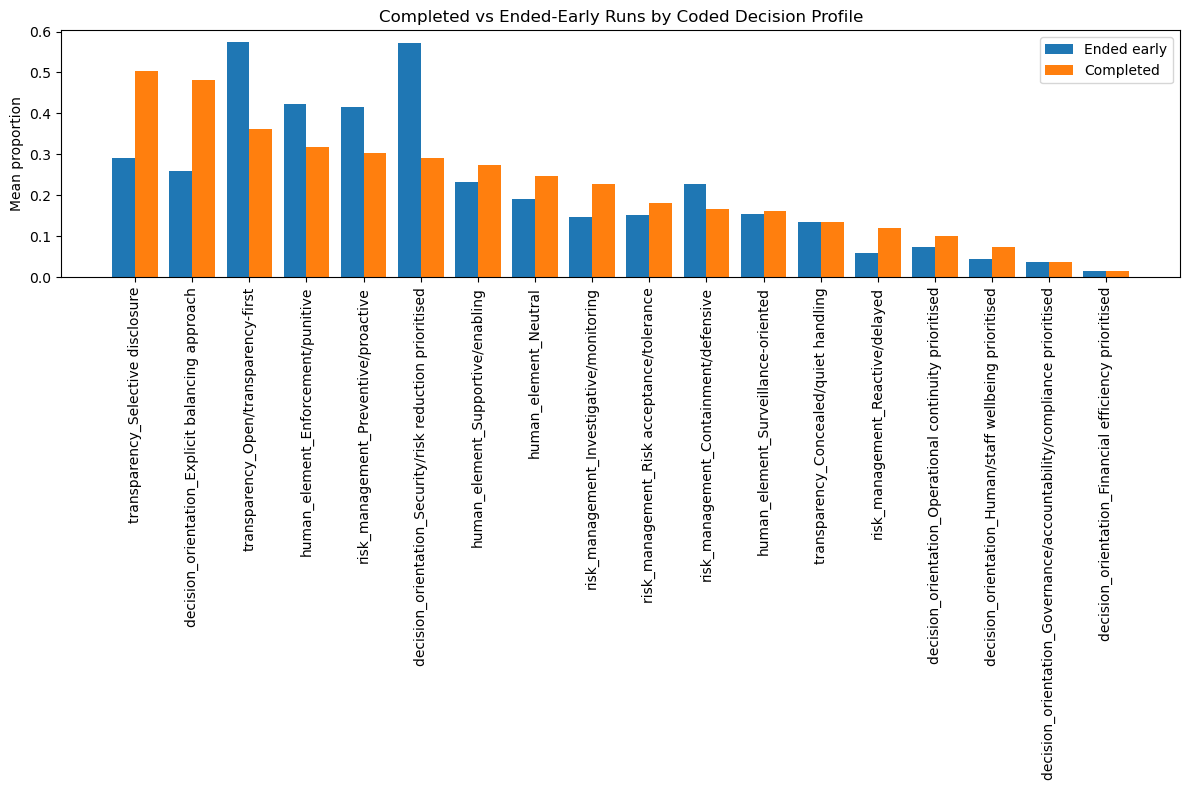

F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\figures\completed_vs_ended_coded_profile.png


In [25]:
import matplotlib.pyplot as plt

comparison_plot = completed_vs_ended_coded_t.copy()
comparison_plot = comparison_plot.sort_values("completed_runs", ascending=False)

plt.figure(figsize=(12, 8))
x = range(len(comparison_plot))

plt.bar(
    [i - 0.2 for i in x],
    comparison_plot["ended_early_runs"],
    width=0.4,
    label="Ended early"
)

plt.bar(
    [i + 0.2 for i in x],
    comparison_plot["completed_runs"],
    width=0.4,
    label="Completed"
)

plt.xticks(x, comparison_plot["category"], rotation=90)
plt.ylabel("Mean proportion")
plt.title("Completed vs Ended-Early Runs by Coded Decision Profile")
plt.legend()
plt.tight_layout()

comparison_fig_file = P.decision_logs_figures_dir / "completed_vs_ended_coded_profile.png"
plt.savefig(comparison_fig_file, dpi=300, bbox_inches="tight")
plt.show()

print(comparison_fig_file)

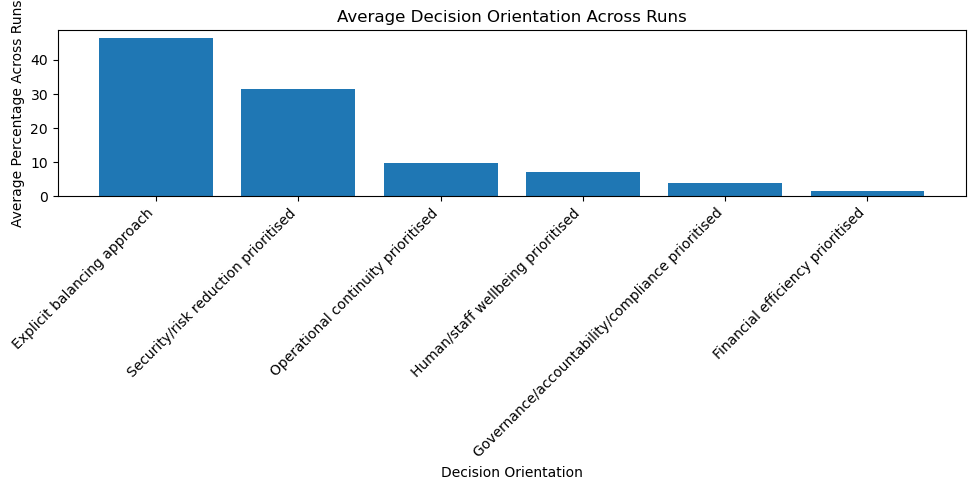

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\figures\average_decision_orientation_across_runs.png


In [26]:
# decision orientation 
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(avg_decision_orientation["category"], avg_decision_orientation["percentage"])
plt.title("Average Decision Orientation Across Runs")
plt.xlabel("Decision Orientation")
plt.ylabel("Average Percentage Across Runs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

decision_orientation_fig_file = P.decision_logs_figures_dir / "average_decision_orientation_across_runs.png"
plt.savefig(decision_orientation_fig_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:")
print(decision_orientation_fig_file)

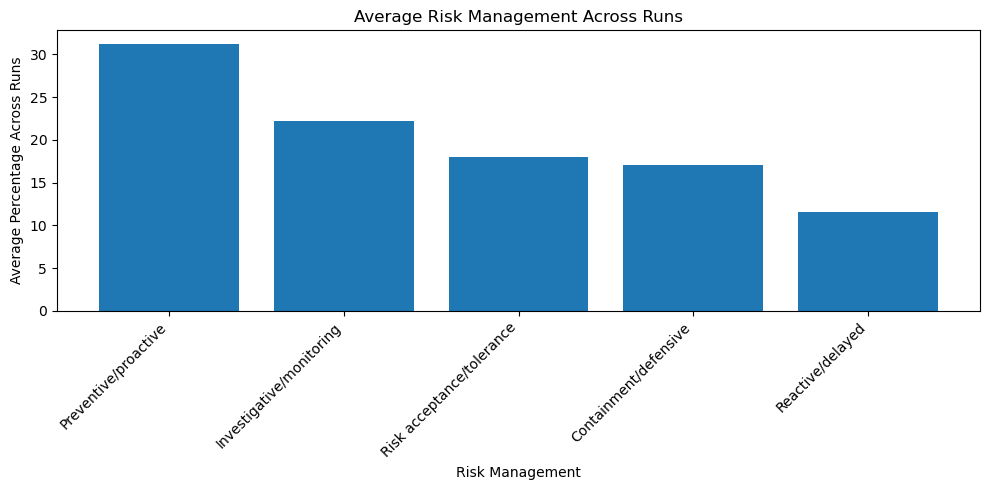

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\figures\average_risk_management_across_runs.png


In [27]:
# risk management
plt.figure(figsize=(10, 5))
plt.bar(avg_risk_management["category"], avg_risk_management["percentage"])
plt.title("Average Risk Management Across Runs")
plt.xlabel("Risk Management")
plt.ylabel("Average Percentage Across Runs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

risk_management_fig_file = P.decision_logs_figures_dir / "average_risk_management_across_runs.png"
plt.savefig(risk_management_fig_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:")
print(risk_management_fig_file)

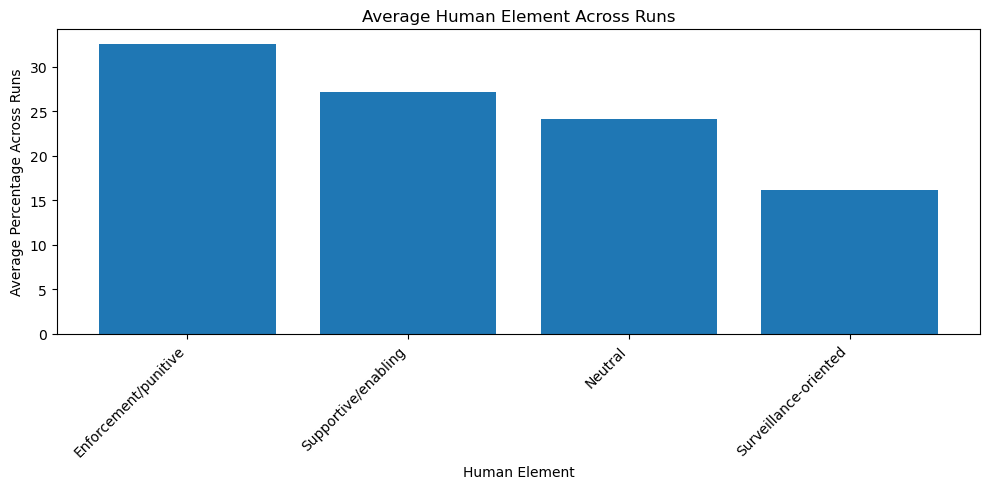

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\figures\average_human_element_across_runs.png


In [28]:
#human element
plt.figure(figsize=(10, 5))
plt.bar(avg_human_element["category"], avg_human_element["percentage"])
plt.title("Average Human Element Across Runs")
plt.xlabel("Human Element")
plt.ylabel("Average Percentage Across Runs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

human_element_fig_file = P.decision_logs_figures_dir / "average_human_element_across_runs.png"
plt.savefig(human_element_fig_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:")
print(human_element_fig_file)

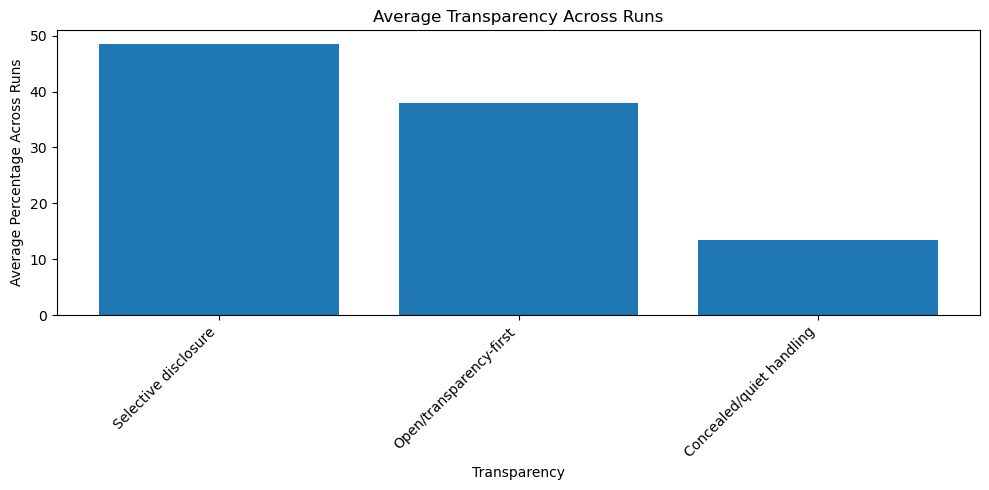

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\figures\average_transparency_across_runs.png


In [29]:
# transparency
plt.figure(figsize=(10, 5))
plt.bar(avg_transparency["category"], avg_transparency["percentage"])
plt.title("Average Transparency Across Runs")
plt.xlabel("Transparency")
plt.ylabel("Average Percentage Across Runs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

transparency_fig_file = P.decision_logs_figures_dir / "average_transparency_across_runs.png"
plt.savefig(transparency_fig_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:")
print(transparency_fig_file)